# Overview of data
JEPXは翌日の任意の30分間における1kWhの値段を表した時系列データで、未来の需給の期待値となっている。

例えば、3月31日の10:00-10:30の価格は3月30日の午後までに入札がされて決定される

正確な定義
>JEPX価格とは、
前日に行われた入札に基づいて決定される、
翌日の各30分時間帯における
電力1kWhあたりの市場クリアリング価格である。

## 概要
- データを結合して分析する
- データを1week平均にする
- 正規分布と対数正規分布でフィッティングし、どちらの分布が価格の分布をよりよく表すかを評価する
- 価格の自己相関、偏自己相関を計算して自己回帰の次数を決定する

In [1]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = REPO_ROOT / "study_with_me"
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import sys
from pathlib import Path

# projectルートを追加
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels
import scipy

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8
scipy: 1.17.1
statsmodels: 0.14.6


In [2]:
dfs = []

for year in range(2016, 2026):
    csv_path = RAW_DATA_DIR / f"electricity/spot_summary_{year}.csv"

    df_year = pd.read_csv(csv_path, encoding="cp932")

    # 年度情報を追加
    df_year["year"] = year

    dfs.append(df_year)

# 縦結合
df = pd.concat(dfs, ignore_index=True)

# 確認
print(df.shape)
df.head()

(175296, 20)


,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
0,2016/04/01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,6.69,6.69,6.69,6.69,4.00,1665000,45000,NaN,NaN,2016
1,2016/04/01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,1979000,195000,NaN,NaN,2016
2,2016/04/01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,2236500,195000,NaN,NaN,2016
3,2016/04/01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,6.03,6.03,6.03,6.03,4.00,2236500,195000,NaN,NaN,2016
4,2016/04/01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,6.57,6.57,6.57,6.57,5.28,2191500,170000,NaN,NaN,2016


In [3]:
df.tail()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
175291,2026/03/31,44,27169050,20317350,16228350,17.91,16.67,16.67,21.21,21.21,15.07,15.07,15.07,7.86,15.07,10002700,1466100,2620150.0,1861100.0,2025
175292,2026/03/31,45,26424300,19738850,15367300,17.79,16.70,16.70,21.00,21.00,13.18,13.18,13.18,7.88,13.18,10205350,1415800,2597750.0,1832650.0,2025
175293,2026/03/31,46,26446950,19070650,14877350,15.72,16.66,16.66,20.50,20.50,13.18,13.18,13.18,13.18,13.18,10354000,1335450,2499100.0,1742250.0,2025
175294,2026/03/31,47,25759000,18647850,14718550,15.07,16.70,16.70,20.20,20.20,13.18,13.18,13.18,13.18,13.18,9925800,1309000,2180300.0,1584550.0,2025
175295,2026/03/31,48,25173350,17490850,14089650,8.50,16.84,16.84,19.70,19.70,8.46,8.46,8.46,8.46,8.46,9379050,1544500,1498800.0,1109450.0,2025


In [4]:
# 日付をdatetime化
df["受渡日"] = pd.to_datetime(df["受渡日"])

# 時刻コード → 30分刻み
df["datetime"] = df["受渡日"] + pd.to_timedelta((df["時刻コード"] - 1) * 30, unit="min")

# indexに設定
df = df.set_index("datetime").sort_index()
df.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
datetime,,,,,,,,,,,,,,,,,,,,
2016-04-01 00:00:00,2016-04-01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,6.69,6.69,6.69,6.69,4.00,1665000,45000,NaN,NaN,2016
2016-04-01 00:30:00,2016-04-01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,1979000,195000,NaN,NaN,2016
2016-04-01 01:00:00,2016-04-01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,2236500,195000,NaN,NaN,2016
2016-04-01 01:30:00,2016-04-01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,6.03,6.03,6.03,6.03,4.00,2236500,195000,NaN,NaN,2016
2016-04-01 02:00:00,2016-04-01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,6.57,6.57,6.57,6.57,5.28,2191500,170000,NaN,NaN,2016


In [5]:
df.tail()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
datetime,,,,,,,,,,,,,,,,,,,,
2026-03-31 21:30:00,2026-03-31,44,27169050,20317350,16228350,17.91,16.67,16.67,21.21,21.21,15.07,15.07,15.07,7.86,15.07,10002700,1466100,2620150.0,1861100.0,2025
2026-03-31 22:00:00,2026-03-31,45,26424300,19738850,15367300,17.79,16.70,16.70,21.00,21.00,13.18,13.18,13.18,7.88,13.18,10205350,1415800,2597750.0,1832650.0,2025
2026-03-31 22:30:00,2026-03-31,46,26446950,19070650,14877350,15.72,16.66,16.66,20.50,20.50,13.18,13.18,13.18,13.18,13.18,10354000,1335450,2499100.0,1742250.0,2025
2026-03-31 23:00:00,2026-03-31,47,25759000,18647850,14718550,15.07,16.70,16.70,20.20,20.20,13.18,13.18,13.18,13.18,13.18,9925800,1309000,2180300.0,1584550.0,2025
2026-03-31 23:30:00,2026-03-31,48,25173350,17490850,14089650,8.50,16.84,16.84,19.70,19.70,8.46,8.46,8.46,8.46,8.46,9379050,1544500,1498800.0,1109450.0,2025


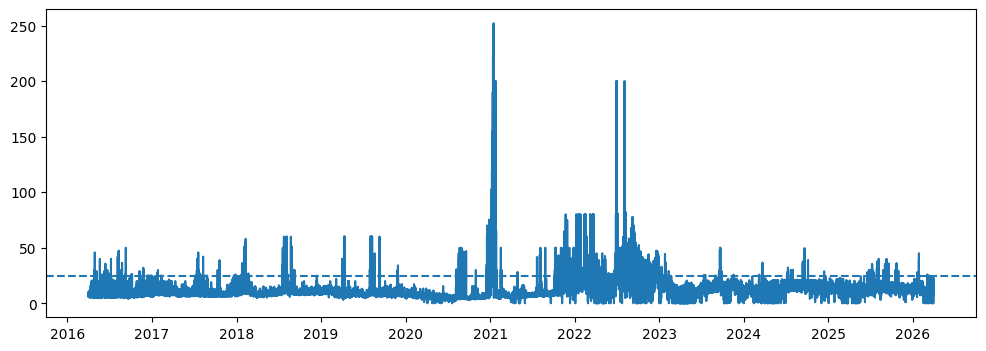

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df["エリアプライス東京(円/kWh)"])
plt.axhline(y=25, linestyle="--")
plt.show()

# 地域ごとのデータフレーム作成

In [7]:
from src.make_dataset import make_dataset
from src.util_plot import plot_price_and_u

In [8]:
df_tokyo = make_dataset(df, area="エリアプライス東京(円/kWh)")

print(df_tokyo.shape)
df_tokyo.head()

(175296, 6)


,slot,is_holiday,price,price_scaled,u,x
datetime,,,,,,
2016-04-01 00:00:00,1,False,6.69,6.69,0,0.0
2016-04-01 00:30:00,2,False,6.34,6.34,0,0.0
2016-04-01 01:00:00,3,False,6.34,6.34,0,0.0
2016-04-01 01:30:00,4,False,6.03,6.03,0,0.0
2016-04-01 02:00:00,5,False,6.57,6.57,0,0.0


In [9]:
# 保存先
output_path = PROJECT_DATA_DIR / "processed/electricity/price_tokyo.csv"

# CSV出力
df_tokyo.to_csv(output_path, encoding="utf-8-sig")

print(f"saved: {output_path}")

saved: ..\data\processed\electricity\price_tokyo.csv


In [10]:
tokyo = pd.read_csv((PROJECT_DATA_DIR / "processed/electricity/price_tokyo.csv"))
tokyo["datetime"] = pd.to_datetime(tokyo["datetime"])

tokyo = tokyo.set_index("datetime")

tokyo.head()

,slot,is_holiday,price,price_scaled,u,x
datetime,,,,,,
2016-04-01 00:00:00,1,False,6.69,6.69,0,0.0
2016-04-01 00:30:00,2,False,6.34,6.34,0,0.0
2016-04-01 01:00:00,3,False,6.34,6.34,0,0.0
2016-04-01 01:30:00,4,False,6.03,6.03,0,0.0
2016-04-01 02:00:00,5,False,6.57,6.57,0,0.0


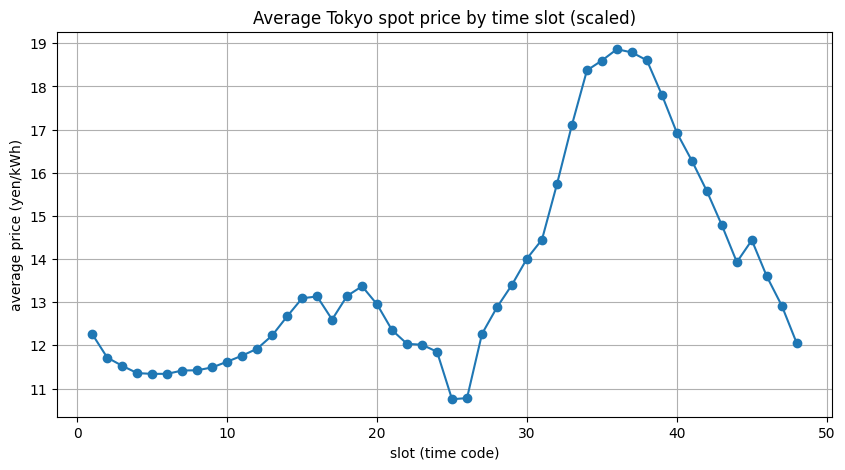

In [11]:
# slotごとの平均
slot_mean = df_tokyo.groupby("slot")["price_scaled"].mean()

# プロット
plt.figure(figsize=(10, 5))
plt.plot(slot_mean.index, slot_mean.values, marker="o")

plt.xlabel("slot (time code)")
plt.ylabel("average price (yen/kWh)")
plt.title("Average Tokyo spot price by time slot (scaled)")
plt.grid(True)
plt.show()

In [12]:
# 夕方がピーク
print(slot_mean.max())
print(slot_mean.idxmax())

18.861459622087228
36


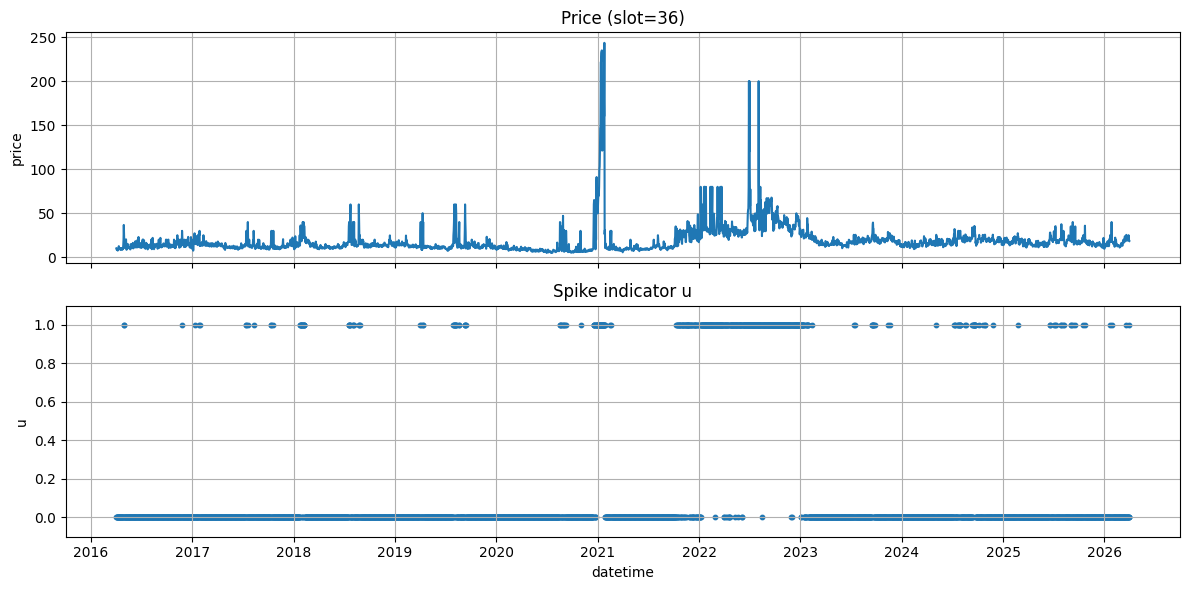

In [13]:
plot_price_and_u(df_tokyo, slot_mean.idxmax())

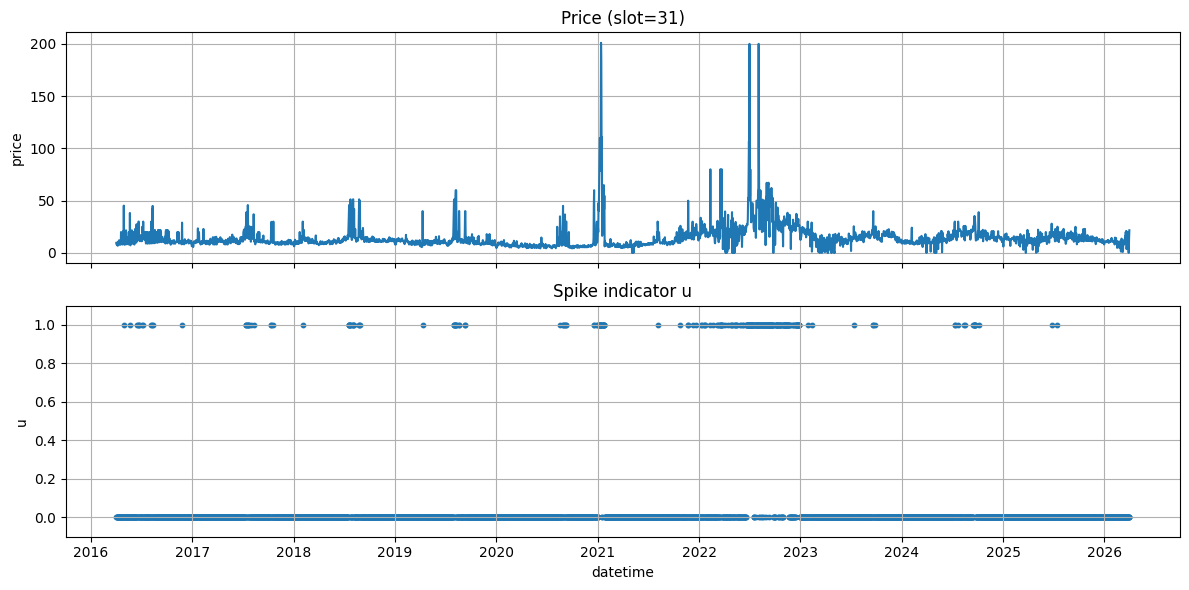

In [14]:
plot_price_and_u(df_tokyo, (slot_mean - slot_mean.quantile(0.75)).abs().idxmin())

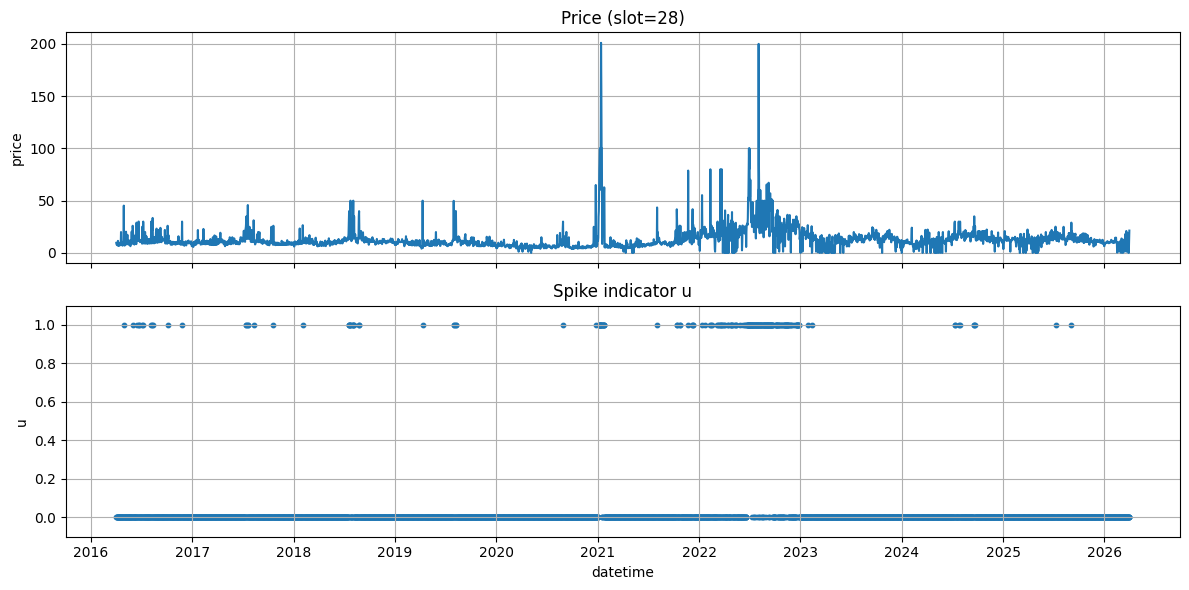

In [15]:
plot_price_and_u(df_tokyo, (slot_mean - slot_mean.median()).abs().idxmin())

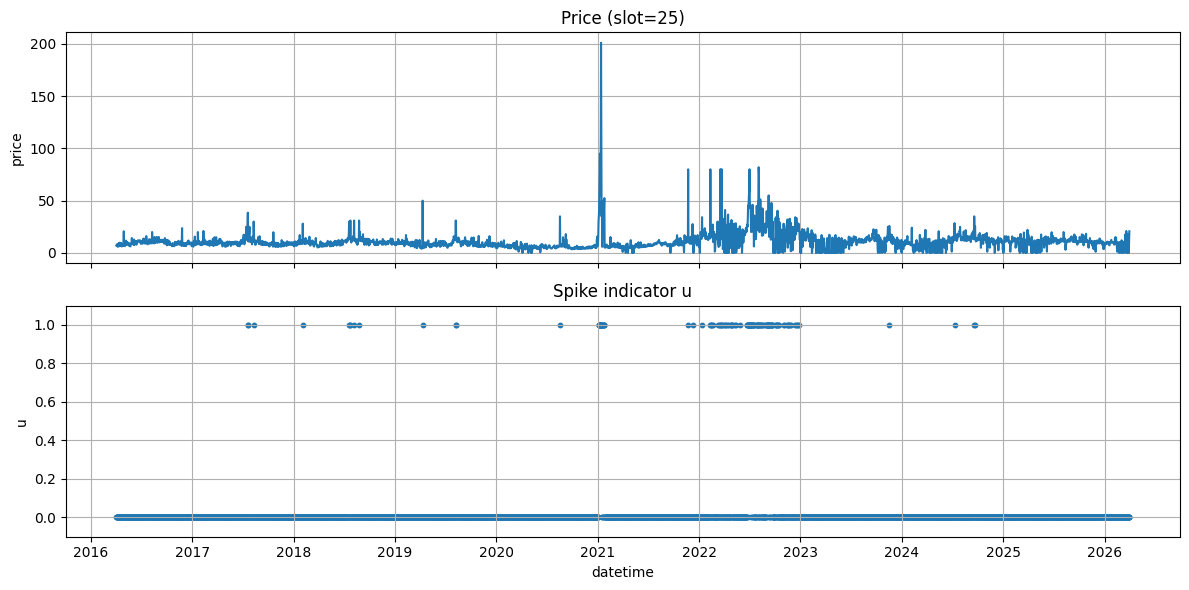

In [16]:
plot_price_and_u(df_tokyo, slot_mean.idxmin())

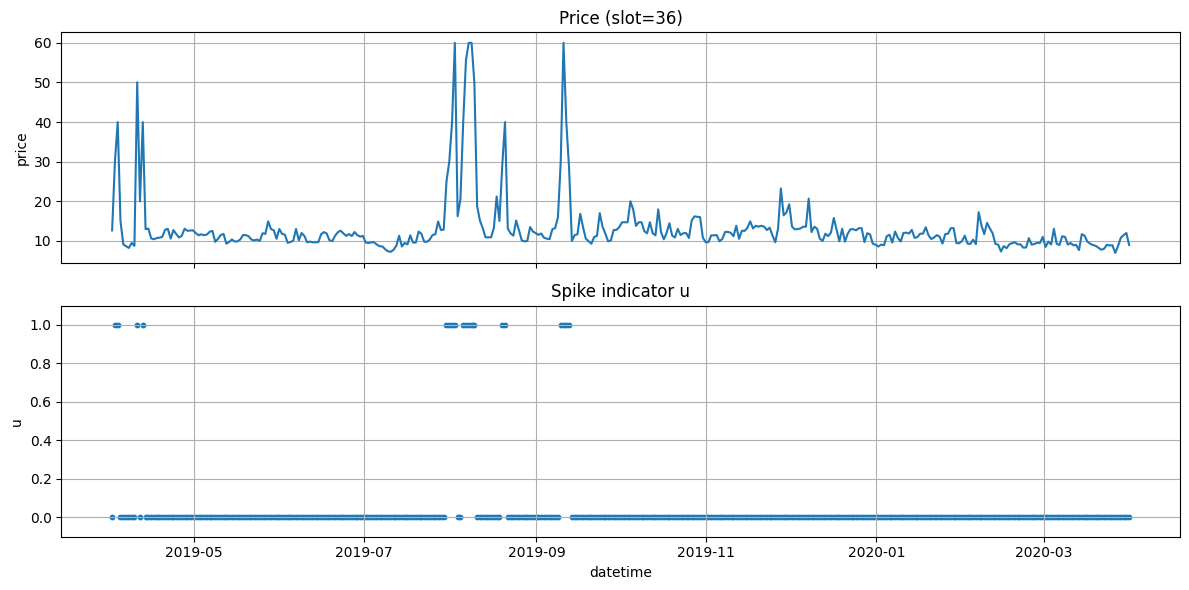

In [17]:
df_tokyo_2019 = df_tokyo.loc["2019-04-01":"2020-03-31"]
plot_price_and_u(df_tokyo_2019, slot_mean.idxmax())

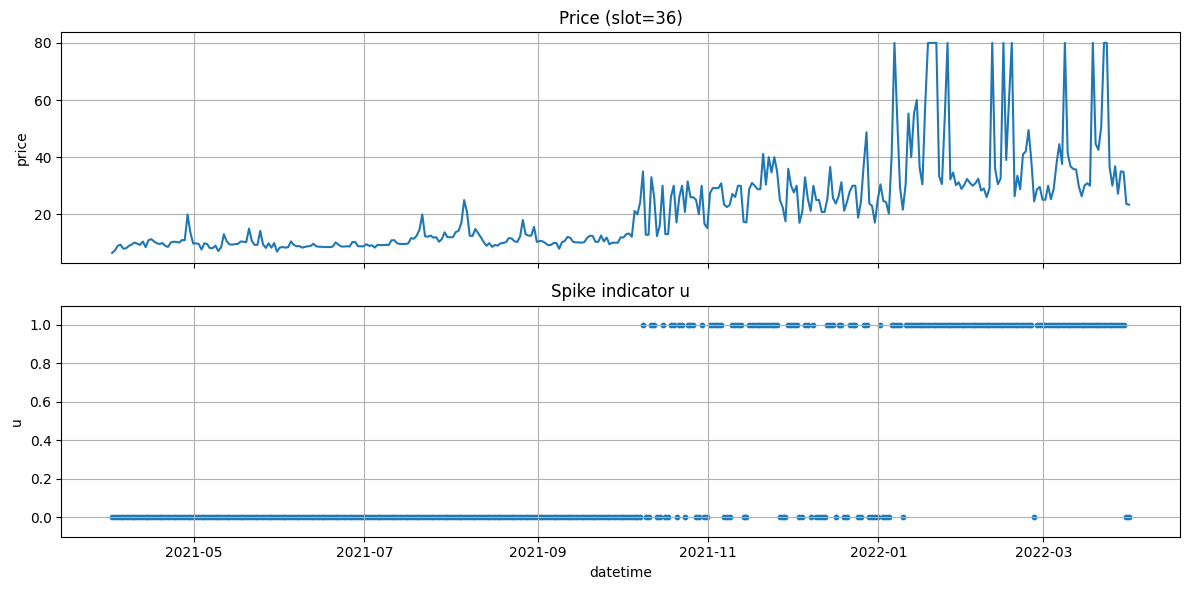

In [18]:
df_tokyo_2021 = df_tokyo.loc["2021-04-01":"2022-03-31"]
plot_price_and_u(df_tokyo_2021, slot_mean.idxmax())

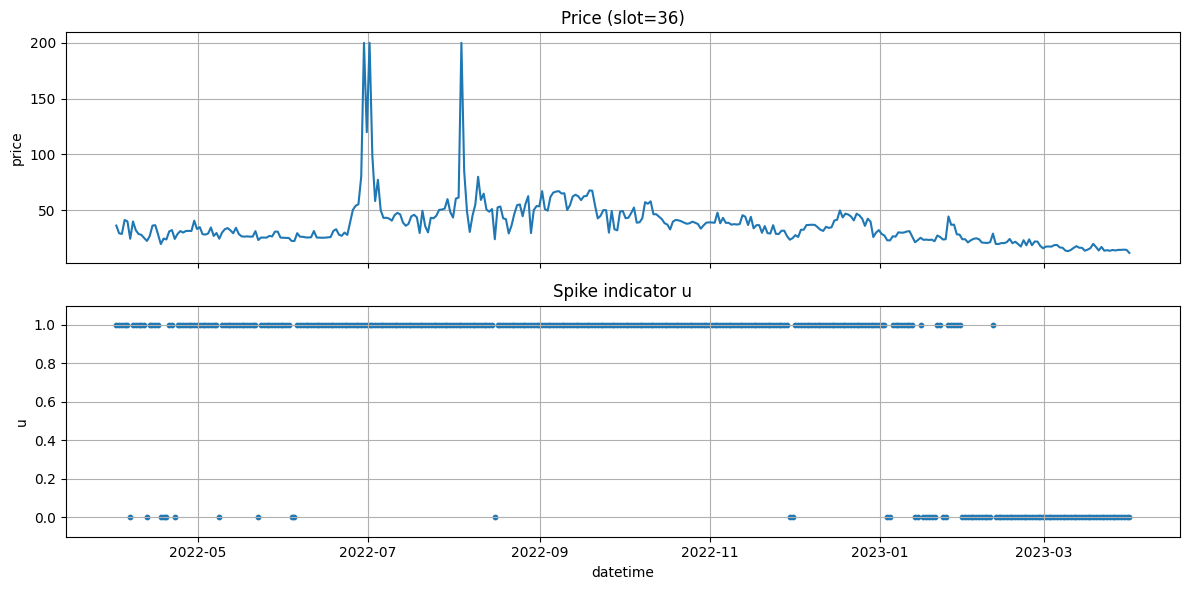

In [19]:
df_tokyo_2022 = df_tokyo.loc["2022-04-01":"2023-03-31"]
plot_price_and_u(df_tokyo_2022, slot_mean.idxmax())

# Weekly average price distribution

## Base

東京プライスを用いて図1の再現を実施

weekly average price has a left-skewed distribution and is closer to the lognormal distribution

left-skewはおかしいのでright-skewが妥当

In [20]:
price_col = "エリアプライス東京(円/kWh)"

df_base = df[[price_col]].copy()

weekly_base = df_base.resample("W").mean()
len(weekly_base)

523

In [21]:
weekly_base.skew()
# skew > 0 より、右袖に長い分布ということがわかる

エリアプライス東京(円/kWh)    5.634694
dtype: float64

In [22]:
weekly_base.head()

,エリアプライス東京(円/kWh)
datetime,
2016-04-03,7.061875
2016-04-10,7.583363
2016-04-17,7.936190
2016-04-24,7.734077
2016-05-01,10.593512


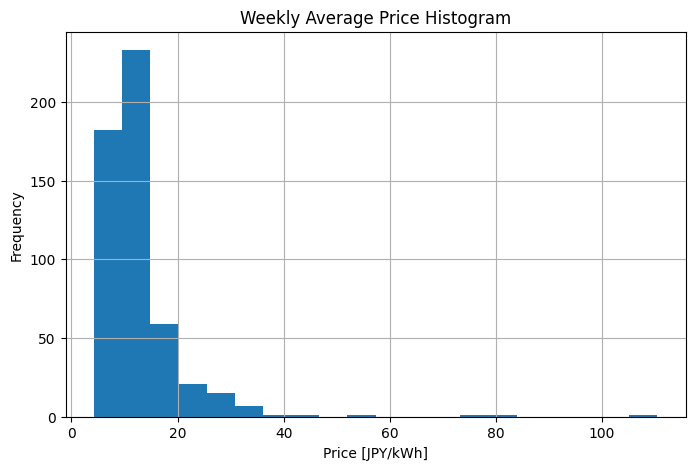

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(weekly_base, bins=20)

plt.title("Weekly Average Price Histogram")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

The weekly average price is closer to the lognormal distribution than the normal distribution

In [24]:
from scipy.stats import norm, lognorm

Normal
mu    = 12.7382
sigma = 8.4033
logLik = -1855.3774
AIC    = 3714.7549

Lognormal
shape = 0.4316
loc   = 0.0000
scale = 11.3826
logLik = -1574.6551
AIC    = 3153.3102

AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。


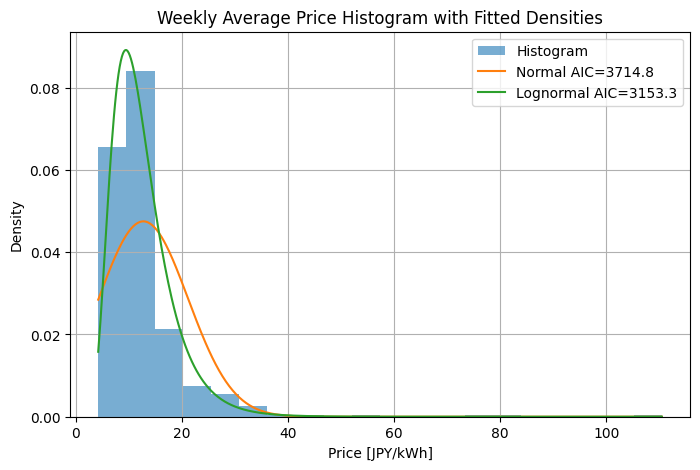

In [25]:
# -----------------------------
# データを1次元配列にする
# -----------------------------
x = weekly_base.squeeze().dropna().values

# 価格は正の値だけ使う
x = x[x > 0]

# -----------------------------
# 1. Normal fit
# -----------------------------
mu_norm, sigma_norm = norm.fit(x)

loglik_norm = np.sum(norm.logpdf(x, loc=mu_norm, scale=sigma_norm))

k_norm = 2  # mu, sigma
aic_norm = 2 * k_norm - 2 * loglik_norm

# -----------------------------
# 2. Lognormal fit
# -----------------------------
shape_lognorm, loc_lognorm, scale_lognorm = lognorm.fit(x, floc=0)

loglik_lognorm = np.sum(
    lognorm.logpdf(x, s=shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)
)

k_lognorm = 2  # shape, scale。locは floc=0 で固定しているので数えない
aic_lognorm = 2 * k_lognorm - 2 * loglik_lognorm

# -----------------------------
# 3. 結果表示
# -----------------------------
print("Normal")
print(f"mu    = {mu_norm:.4f}")
print(f"sigma = {sigma_norm:.4f}")
print(f"logLik = {loglik_norm:.4f}")
print(f"AIC    = {aic_norm:.4f}")

print()

print("Lognormal")
print(f"shape = {shape_lognorm:.4f}")
print(f"loc   = {loc_lognorm:.4f}")
print(f"scale = {scale_lognorm:.4f}")
print(f"logLik = {loglik_lognorm:.4f}")
print(f"AIC    = {aic_lognorm:.4f}")

print()

if aic_lognorm < aic_norm:
    print(
        "AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。"
    )
else:
    print("AICは Normal の方が小さいです。正規分布の方がよくフィットしています。")

# -----------------------------
# 4. ヒストグラム + fitted density
# -----------------------------
xs = np.linspace(x.min(), x.max(), 500)

pdf_norm = norm.pdf(xs, loc=mu_norm, scale=sigma_norm)

pdf_lognorm = lognorm.pdf(xs, s=shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)

plt.figure(figsize=(8, 5))

plt.hist(x, bins=20, density=True, alpha=0.6, label="Histogram")

plt.plot(xs, pdf_norm, label=f"Normal AIC={aic_norm:.1f}")

plt.plot(xs, pdf_lognorm, label=f"Lognormal AIC={aic_lognorm:.1f}")

plt.title("Weekly Average Price Histogram with Fitted Densities")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

## Daytime 
日中8:00から18:00に限った話

In [26]:
price_col = "エリアプライス東京(円/kWh)"

# -----------------------------
# daytime data
# 平日 08:00-18:00
# -----------------------------
df_daytime = df[[price_col]].copy()

# 平日だけ
df_daytime = df_daytime[df_daytime.index.weekday < 5]

# 08:00-18:00
df_daytime = df_daytime.between_time("08:00", "18:00")

# -----------------------------
# weekly average
# -----------------------------
weekly_daytime = df_daytime.resample("W").mean()

weekly_daytime.head()

,エリアプライス東京(円/kWh)
datetime,
2016-04-03,9.380952
2016-04-10,8.811333
2016-04-17,9.627619
2016-04-24,9.952667
2016-05-01,16.528476


Daytime weekly average price
skewness = 6.6605

Normal
mu     = 14.5213
sigma  = 11.1892
logLik = -2005.1227
AIC    = 4014.2454

Lognormal
shape  = 0.4697
loc    = 0.0000
scale  = 12.6728
logLik = -1675.0498
AIC    = 3354.0995

AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。


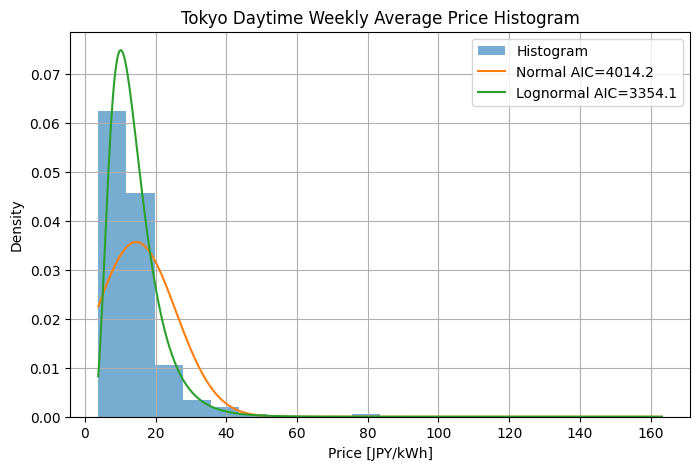

In [27]:
# -----------------------------
# Daytime weekly data
# -----------------------------
x = weekly_daytime.squeeze().dropna().values
x = x[x > 0]

# -----------------------------
# Skewness
# -----------------------------
skew_value = pd.Series(x).skew()

print("Daytime weekly average price")
print(f"skewness = {skew_value:.4f}")

# -----------------------------
# Normal fit
# -----------------------------
mu_norm, sigma_norm = norm.fit(x)
loglik_norm = np.sum(norm.logpdf(x, loc=mu_norm, scale=sigma_norm))

k_norm = 2
aic_norm = 2 * k_norm - 2 * loglik_norm

# -----------------------------
# Lognormal fit
# -----------------------------
shape_lognorm, loc_lognorm, scale_lognorm = lognorm.fit(x, floc=0)

loglik_lognorm = np.sum(
    lognorm.logpdf(x, s=shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)
)

k_lognorm = 2
aic_lognorm = 2 * k_lognorm - 2 * loglik_lognorm

# -----------------------------
# Result
# -----------------------------
print()
print("Normal")
print(f"mu     = {mu_norm:.4f}")
print(f"sigma  = {sigma_norm:.4f}")
print(f"logLik = {loglik_norm:.4f}")
print(f"AIC    = {aic_norm:.4f}")

print()
print("Lognormal")
print(f"shape  = {shape_lognorm:.4f}")
print(f"loc    = {loc_lognorm:.4f}")
print(f"scale  = {scale_lognorm:.4f}")
print(f"logLik = {loglik_lognorm:.4f}")
print(f"AIC    = {aic_lognorm:.4f}")

print()
if aic_lognorm < aic_norm:
    print(
        "AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。"
    )
else:
    print("AICは Normal の方が小さいです。正規分布の方がよくフィットしています。")

# -----------------------------
# Plot
# -----------------------------
xs = np.linspace(x.min(), x.max(), 500)

pdf_norm = norm.pdf(xs, loc=mu_norm, scale=sigma_norm)

pdf_lognorm = lognorm.pdf(xs, s=shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)

plt.figure(figsize=(8, 5))

plt.hist(x, bins=20, density=True, alpha=0.6, label="Histogram")

plt.plot(xs, pdf_norm, label=f"Normal AIC={aic_norm:.1f}")

plt.plot(xs, pdf_lognorm, label=f"Lognormal AIC={aic_lognorm:.1f}")

plt.title("Tokyo Daytime Weekly Average Price Histogram")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

そもそもだが2022年は別市場に見えるくらい価格の変化が激しい

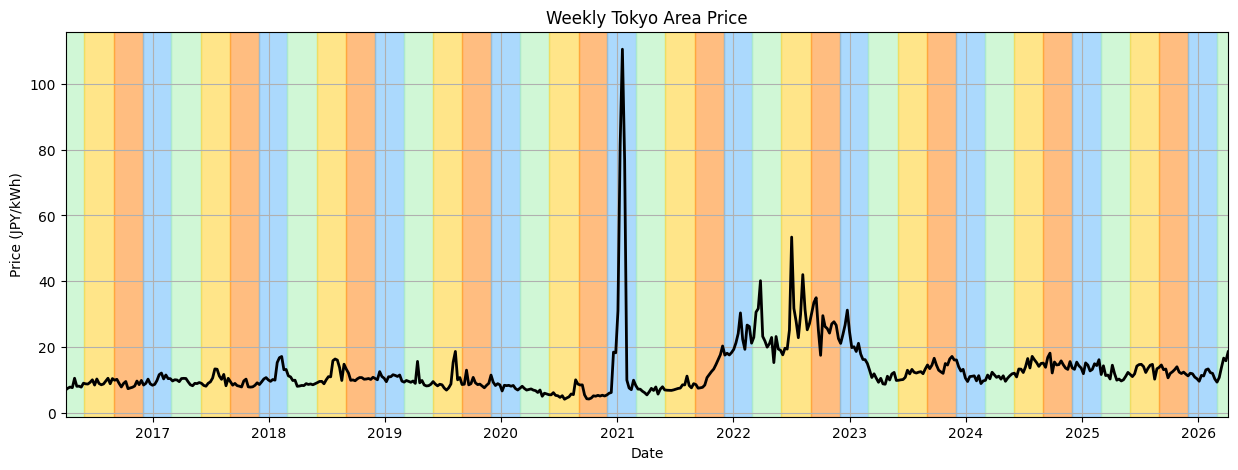

In [28]:
# 時系列プロット
fig, ax = plt.subplots(figsize=(15, 5))

season_colors = {
    "spring": "#b2f2bb",  # 黄緑
    "summer": "#ffd43b",  # 黄色
    "autumn": "#ff922b",  # オレンジ
    "winter": "#74c0fc",  # 水色
}

years = range(weekly_base.index.min().year, weekly_base.index.max().year + 1)

for year in years:
    seasons = [
        ("spring", f"{year}-03-01", f"{year}-06-01"),
        ("summer", f"{year}-06-01", f"{year}-09-01"),
        ("autumn", f"{year}-09-01", f"{year}-12-01"),
        ("winter", f"{year}-12-01", f"{year + 1}-03-01"),
    ]

    for season, start, end in seasons:
        ax.axvspan(
            pd.to_datetime(start),
            pd.to_datetime(end),
            color=season_colors[season],
            alpha=0.6,
        )

# 折れ線
ax.plot(
    weekly_base.index,
    weekly_base["エリアプライス東京(円/kWh)"],
    linewidth=2,
    color="black",
)

# データ範囲に合わせる
ax.set_xlim(weekly_base.index.min(), weekly_base.index.max())

ax.set_title("Weekly Tokyo Area Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price (JPY/kWh)")
ax.grid(True)

plt.show()

In [29]:
weekly_base = weekly_base.rename(columns={"エリアプライス東京(円/kWh)": "tokyo_price"})

weekly_base.head()

,tokyo_price
datetime,
2016-04-03,7.061875
2016-04-10,7.583363
2016-04-17,7.936190
2016-04-24,7.734077
2016-05-01,10.593512


In [30]:
weekly_daytime = weekly_daytime.rename(
    columns={"エリアプライス東京(円/kWh)": "tokyo_price"}
)
weekly_daytime.head()

,tokyo_price
datetime,
2016-04-03,9.380952
2016-04-10,8.811333
2016-04-17,9.627619
2016-04-24,9.952667
2016-05-01,16.528476


In [31]:
weekly_base = weekly_base.copy()
weekly_base["log_tokyo_price"] = np.log(weekly_base["tokyo_price"])
weekly_base.head()

,tokyo_price,log_tokyo_price
datetime,,
2016-04-03,7.061875,1.954711
2016-04-10,7.583363,2.025957
2016-04-17,7.936190,2.071433
2016-04-24,7.734077,2.045636
2016-05-01,10.593512,2.360242


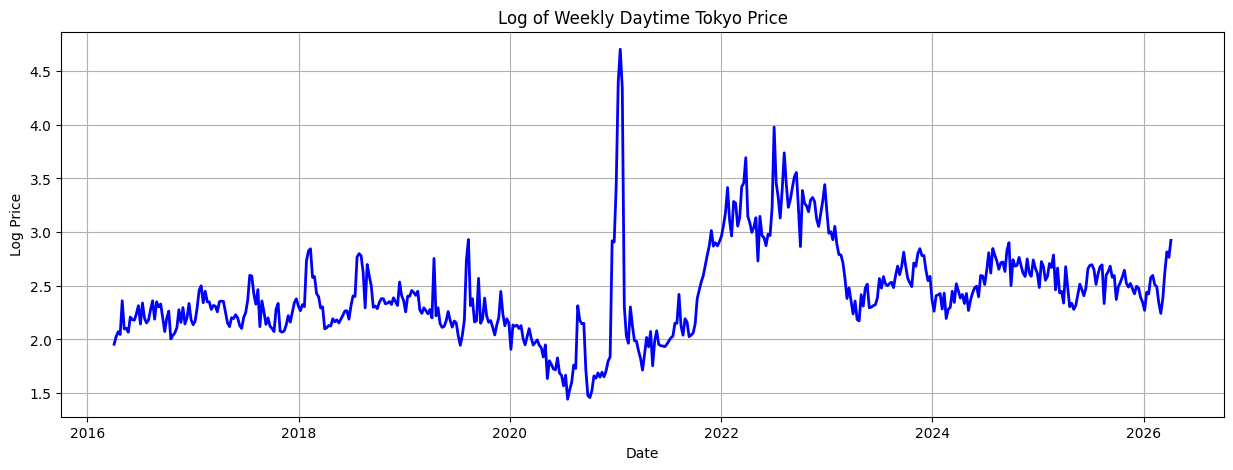

In [32]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(weekly_base.index, weekly_base["log_tokyo_price"], linewidth=2, color="blue")
ax.set_title("Log of Weekly Daytime Tokyo Price")
ax.set_xlabel("Date")
ax.set_ylabel("Log Price")
ax.grid(True)
plt.show()

In [33]:
weekly_daytime = weekly_daytime.rename(
    columns={"エリアプライス東京(円/kWh)": "tokyo_price"}
)
weekly_daytime.head()

,tokyo_price
datetime,
2016-04-03,9.380952
2016-04-10,8.811333
2016-04-17,9.627619
2016-04-24,9.952667
2016-05-01,16.528476


In [34]:
weekly_daytime = weekly_daytime.copy()
weekly_daytime["log_tokyo_price"] = np.log(weekly_daytime["tokyo_price"])
weekly_daytime.head()

,tokyo_price,log_tokyo_price
datetime,,
2016-04-03,9.380952,2.238681
2016-04-10,8.811333,2.176039
2016-04-17,9.627619,2.264636
2016-04-24,9.952667,2.297841
2016-05-01,16.528476,2.805085


In [35]:
from pathlib import Path

print(Path.cwd())

c:\Users\h20s1\workspace\jepx-data-analytics\study_with_me\1.data_processing


In [36]:
# 保存先
output_path = PROJECT_DATA_DIR / "processed/electricity/weekly_base.csv"

# ディレクトリがなければ作成
output_path.parent.mkdir(parents=True, exist_ok=True)

# CSV出力
weekly_base.to_csv(output_path, encoding="utf-8-sig")

print(f"saved: {output_path}")

saved: ..\data\processed\electricity\weekly_base.csv


In [37]:
# 保存先
output_path = PROJECT_DATA_DIR / "processed/electricity/weekly_daytime.csv"

# ディレクトリがなければ作成
output_path.parent.mkdir(parents=True, exist_ok=True)

# CSV出力
weekly_daytime.to_csv(output_path, encoding="utf-8-sig")

print(f"saved: {output_path}")

saved: ..\data\processed\electricity\weekly_daytime.csv
